# Vizualizācijas ar pandas un matplotlib

In [1]:
# ielādējam pandas bibliotēku
import pandas as pd
# kāda versija
print("Pandas versija:", pd.__version__)

Pandas versija: 3.0.1


In [2]:
# ielādējam datus no CSV faila
df = pd.read_csv("terini.csv") # nomainiet "terini.csv" uz jūsu datu faila nosaukumu
# apskatīsim visu tabulu
df

,Diena,Tēriņi
0,Pirmdiena,30.70
1,Otrdiena,25.50
2,Trešdiena,28.90
3,Ceturtdiena,22.40
4,Piektdiena,35.20
5,Sestdiena,40.00
6,Svētdiena,18.75


In [3]:
# uzstādam Diena par indeksu, lai varētu vieglāk strādāt ar datiem
df.set_index("Diena", inplace=True) # set_index() funkcija ļauj iestatīt konkrētu kolonnu kā indeksu, inplace=True nozīmē, ka izmaiņas tiks veiktas esošajā datu rāmī, nevis tiks izveidots jauns datu rāmis
df

,Tēriņi
Diena,
Pirmdiena,30.70
Otrdiena,25.50
Trešdiena,28.90
Ceturtdiena,22.40
Piektdiena,35.20
Sestdiena,40.00
Svētdiena,18.75


<Axes: xlabel='Diena'>

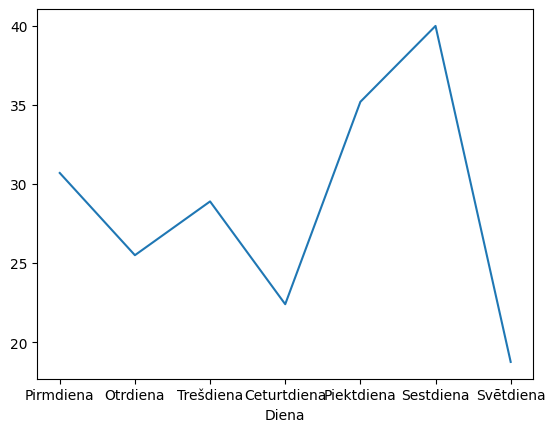

In [ ]:
df["Tēriņi"].plot() # izveidojam līniju grafiku, kur x ass ir Diena (indekss)
# un y vērtība ir Tērīņi kolonna

<Axes: xlabel='Diena'>

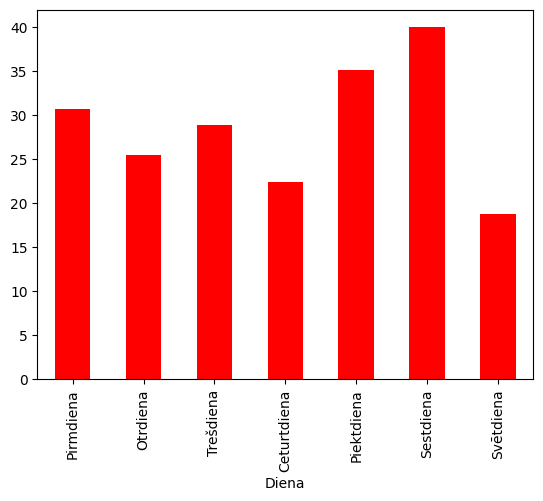

In [6]:
# tagad uzzīmēsim šos pašus datus bet ar stabiņu diagrammu un sarkanā krāsā
df["Tēriņi"].plot(kind="bar", color="red")
# tātad kind ir vizualizācijas tips
# un savukārt krāsa var būt arī uzdota dažādos formātus - atbalsts ir visai krāsu gammai

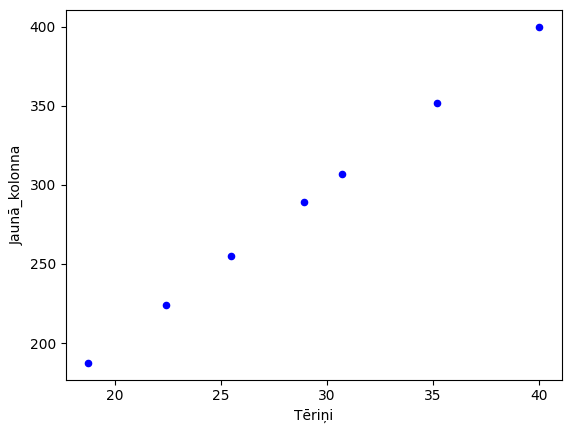

In [11]:
# tagad tos pašus datus bet punktiņu diagrammas formā un gribam arī saglabāt
# bet mums ir tikai viena kollona vajadzētu vēl otru
# let's make another column let's make vērtības 10 uz augšu
df["Jaunā_kolonna"] = df["Tēriņi"] * 10
# lai būtu punktiņu diagrammu
# vajag nodot arī x un y vērtības
# could look in documentation for plot:
# Pandas plot documentation: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html
df.plot(kind="scatter", x="Tēriņi", y="Jaunā_kolonna", color="blue")
# we need matplotlib
import matplotlib.pyplot as plt
# we also want to save the plot
plt.savefig("tēriņi_scatter.png")

In [ ]:
# apskatam vēl vienu piemērum kur mums ienākošie dati ir vārdnīca
dati = {
    "Diena": ["Pirmdiena", "Otrdiena", "Trešdiena", "Ceturtdiena", "Piektdiena", "Sestdiena"],
    "Tēriņi": [20, 35, 30, 35, 27, None]
}

# no šādas vārdnīcas varam izveidot datu rāmi - DataFrame
df2 = pd.DataFrame(dati)
# tātad vārdnīcas atslēgas būs kolonu nosaukumi, bet vērtības būs datu rindiņas
# vērtibām jābūt virknēm (var būt list, tuples, numpy arrays, vai pat pandas Series)
# un tad varam apskatīt šo datu rāmi
df2 # NaN nozīmē kā tukšu vietu, jo nav vērtības

,Diena,Tēriņi
0,Pirmdiena,20.0
1,Otrdiena,35.0
2,Trešdiena,30.0
3,Ceturtdiena,35.0
4,Piektdiena,27.0
5,Sestdiena,NaN


In [ ]:
# bieži vien šādas rindas atmet
# tāda rindas ar tukšam vērtībām var tikt atmetas ar dropna() funkciju
df2.dropna(inplace=True) # inplace=True nozīmē, ka izmaiņas tiks veiktas esošajā datu rāmī, nevis tiks izveidots jauns datu rāmis
df2 # redzam ka Sestdienas rinda ir atmesta, jo tur bija NaN vērtība

,Diena,Tēriņi
0,Pirmdiena,20.0
1,Otrdiena,35.0
2,Trešdiena,30.0
3,Ceturtdiena,35.0
4,Piektdiena,27.0


Text(0.5, 1.0, 'Tēriņi pa dienām')

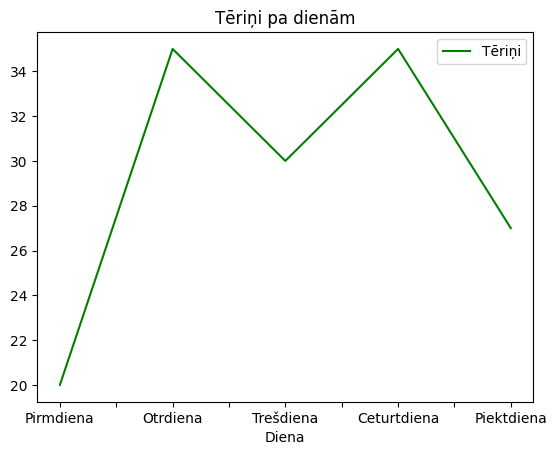

In [22]:
# veidosim līniju grafiku no šiem datiem
df2.plot(x="Diena", y="Tēriņi", kind="line", color="green")
# ir ļoti daudz dažādu formatējumu ko var pievienot šim grafikam, piemēram, pievienot nosaukumu, x un y asu nosaukumus, leģendu, un daudz ko citu
plt.title("Tēriņi pa dienām") # pievienojam virsrakstu


Text(0.5, 1.0, 'Tēriņi pa dienām - stabiņu diagramma')

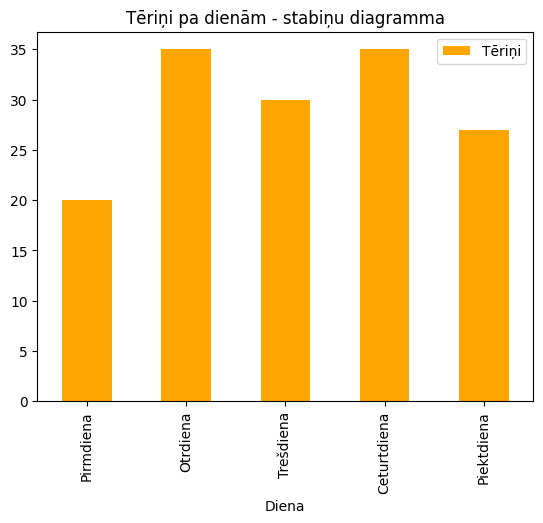

In [23]:
# varam atkal zīmēt stabiņu diagrammu
df2.plot(x="Diena", y="Tēriņi", kind="bar", color="orange")
plt.title("Tēriņi pa dienām - stabiņu diagramma")

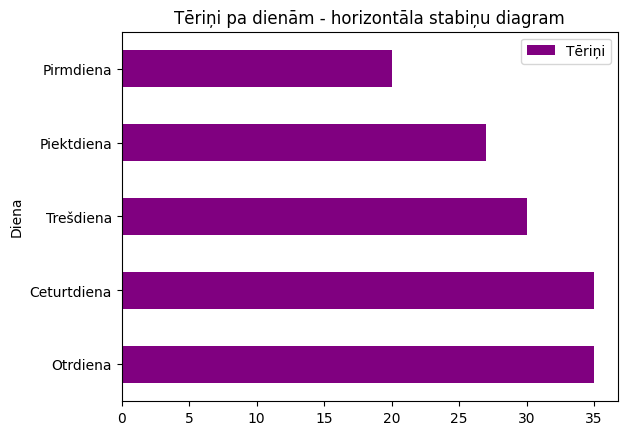

In [24]:
# sakārtosim pēc tēriņiem
df2.sort_values(by="Tēriņi", inplace=True, ascending=False)
# zīmēsim horizontālu stabiņu diagrammu
df2.plot(x="Diena", y="Tēriņi", kind="barh", color="purple")
plt.title("Tēriņi pa dienām - horizontāla stabiņu diagram")
# saglabāsim šo grafiku
plt.savefig("tēriņi_barh.png")